Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH/HClO4 concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different condiitons for each acidic/basic CO oxidation: 4 different setups <br>
Assume that pH reaction order data will be less accurate than CO reaction order or transfer coefficient data - different setups for different pHs <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalysts: Pt100, Pt66Ru33, Pt50Ru50 <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>

In [1]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import _utils

In [2]:
# Experimental conditions (Pt100 KOH) and constants

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
conditions = list(itertools.product(C_KOH_list, P_CO_list))

R, T, F = 8.3145, 298.15, 96485

In [3]:
# Load current density data + classification

current_densities = pd.read_excel('Summary_current_densities.xlsx', sheet_name='Pt100 KOH Current Densities')
experiments = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = current_densities.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'j']
    # Force numeric, coerce bad values to NaN, then drop
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
    subset = subset.dropna()
    experiments[(C_KOH, P_CO)] = subset

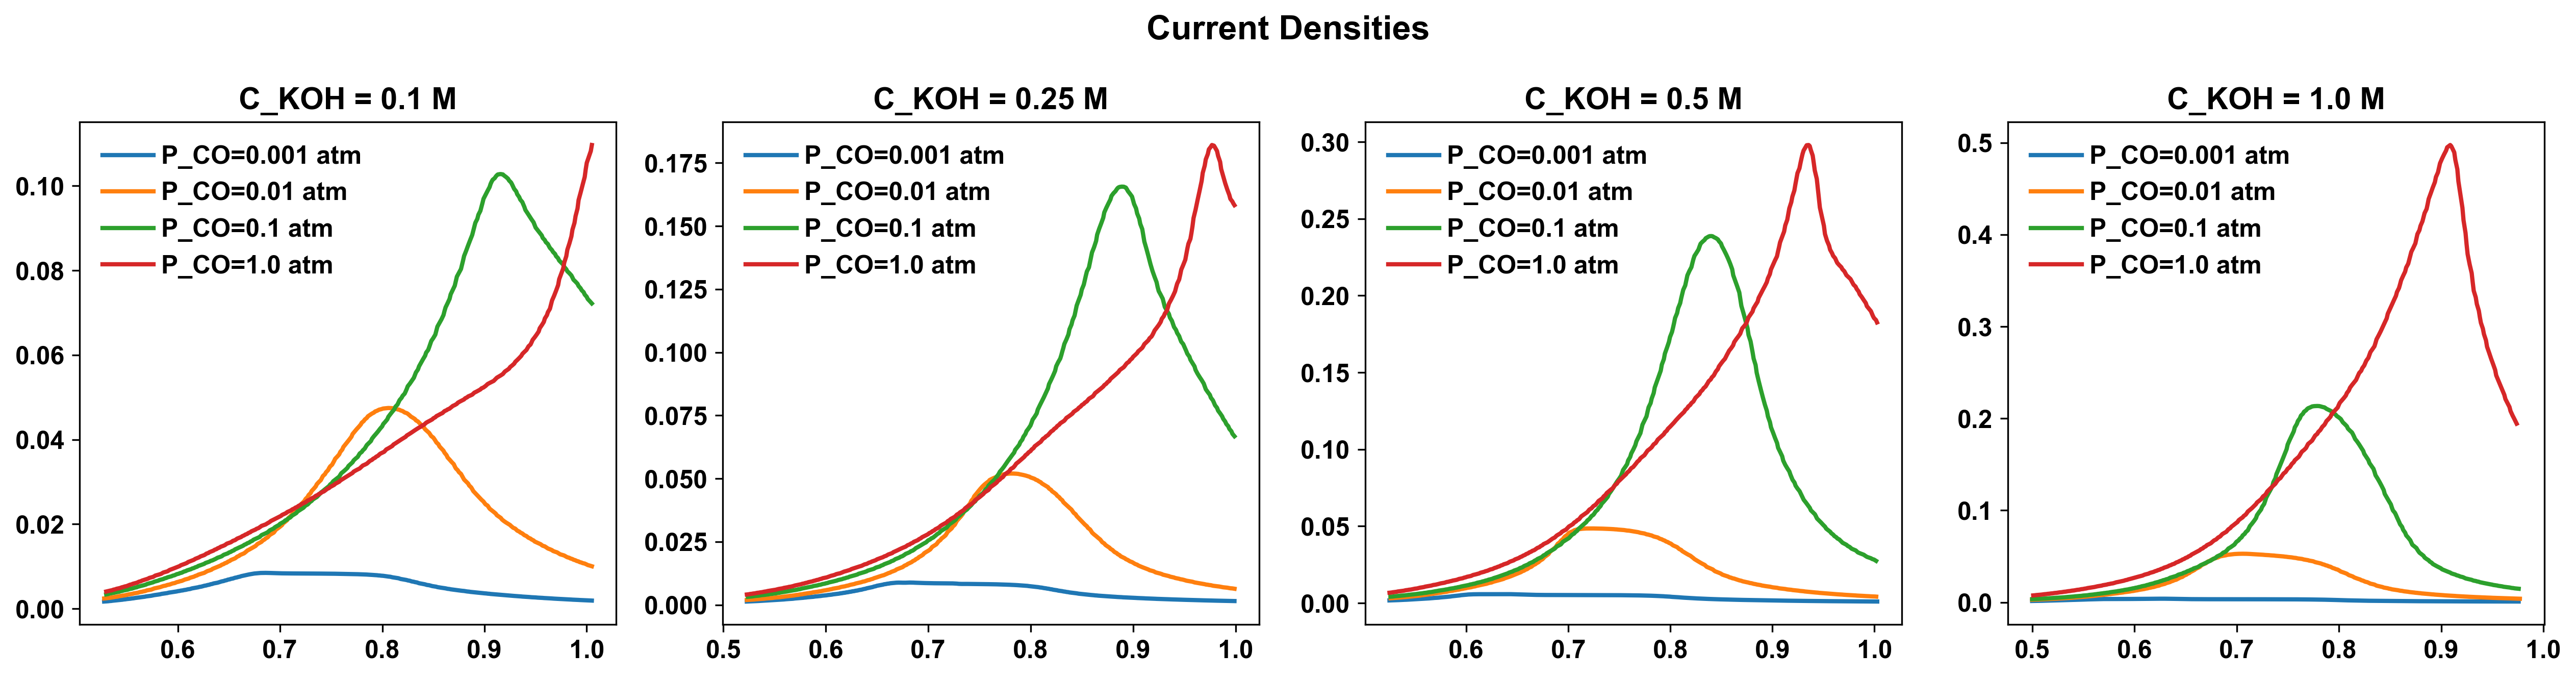

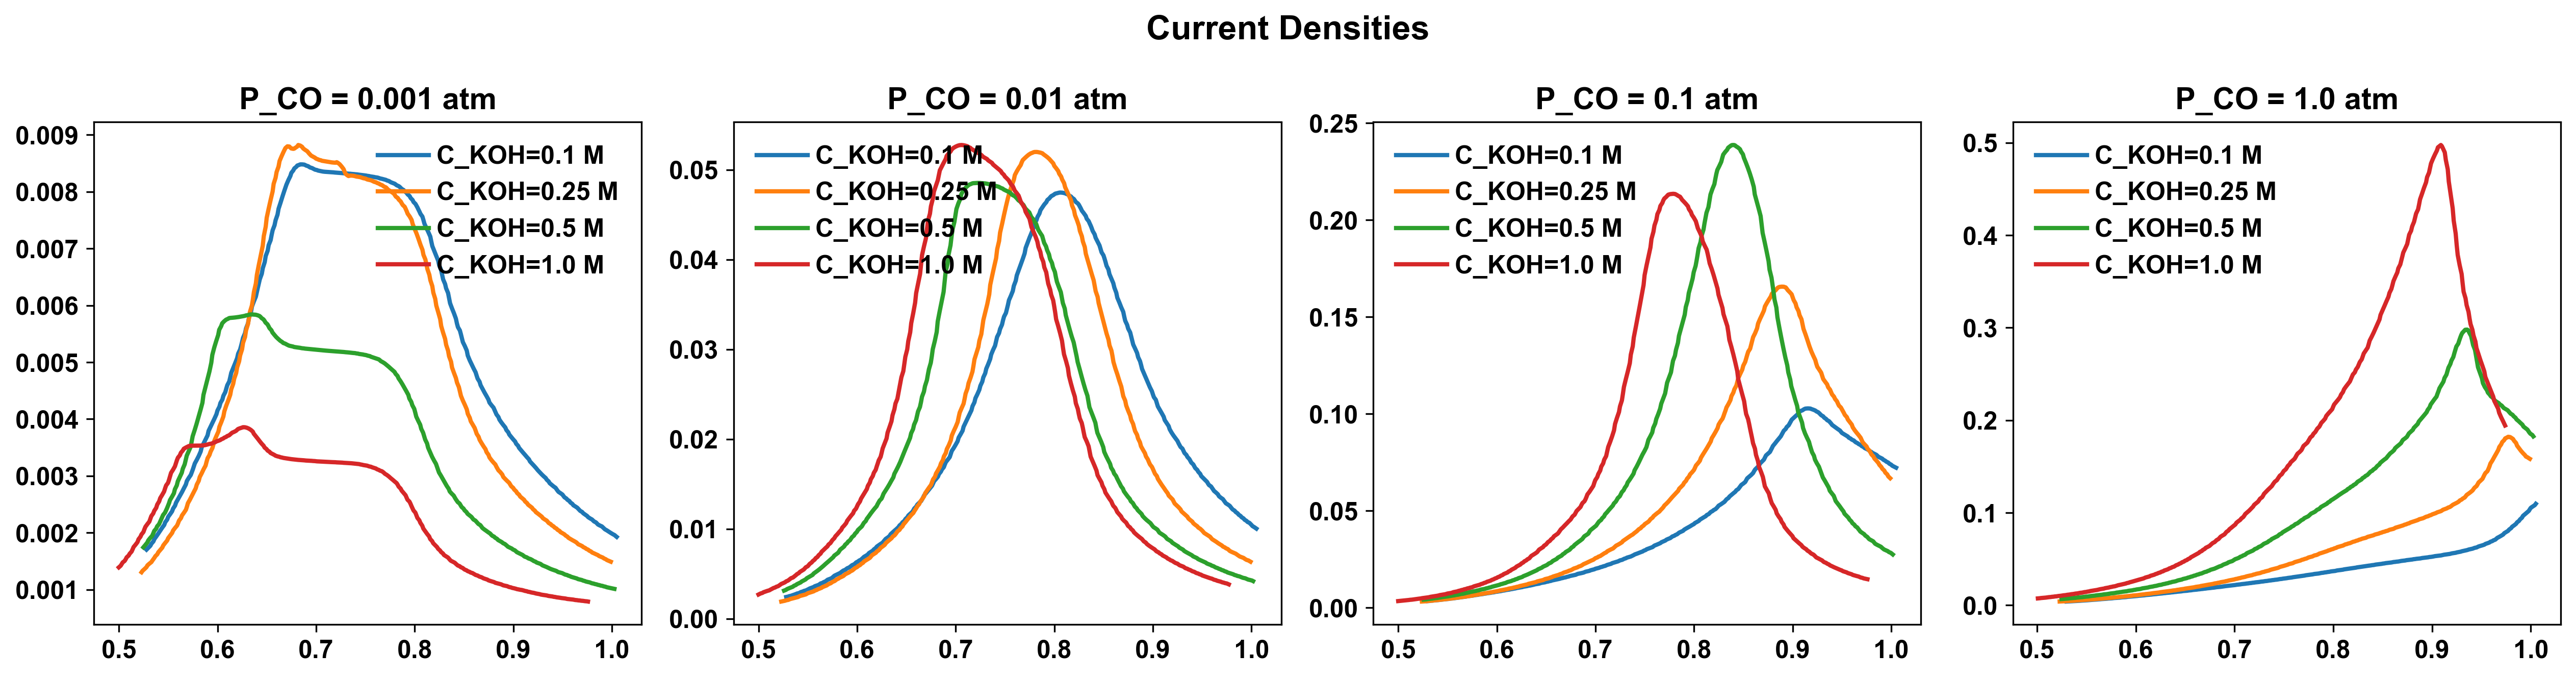

In [8]:
# Plotting current densities 

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions:
        if C_KOH == target_KOH:
            E = experiments[(C_KOH, P_CO)]['E']
            j = experiments[(C_KOH, P_CO)]['j']
            plt.plot(E, j, label=f'P_CO={P_CO} atm')  
    plt.legend()
plt.tight_layout()

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, target_CO in enumerate(P_CO_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {target_CO} atm')
    for (C_KOH, P_CO) in conditions:
        if P_CO == target_CO:
            E = experiments[(C_KOH, P_CO)]['E']
            j = experiments[(C_KOH, P_CO)]['j']
            plt.plot(E, j, label=f'C_KOH={C_KOH} M')  
    plt.legend()
plt.tight_layout()

In [5]:
# Load Todd's alpha data + classification

alpha_todd_raw = pd.read_excel('Summary_TCs.xlsx', sheet_name='Pt100 KOH')
alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'alpha']
    subset = subset.dropna()
    alpha_todd[(C_KOH, P_CO)] = subset

In [6]:
# Calculate alpha from current data

for condition in experiments:
    E = experiments[condition]['E']
    j = experiments[condition]['j']
    lnj = np.log(j)

    alpha = (R*T/F)*np.gradient(lnj, E)    
    experiments[condition]['alpha'] = alpha

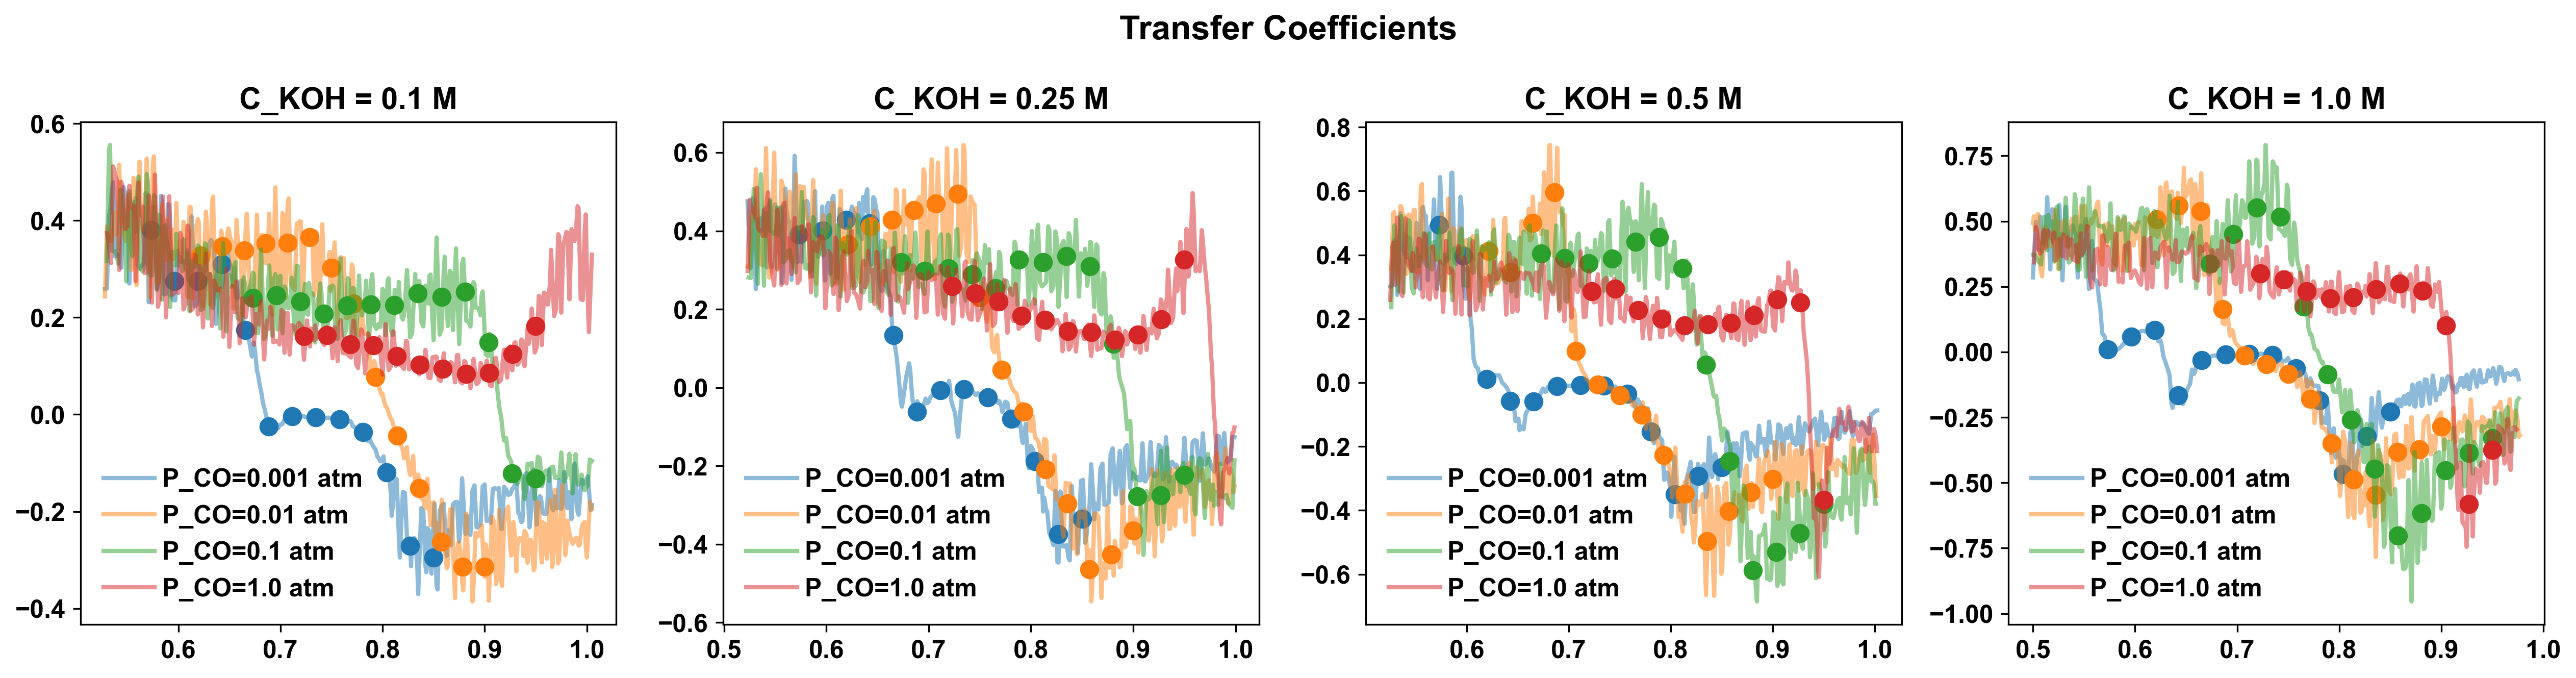

In [7]:
# Plotting alphas

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions:
        if C_KOH == target_KOH:
            E = experiments[(C_KOH, P_CO)]['E']
            alpha = experiments[(C_KOH, P_CO)]['alpha']
            line, = plt.plot(E, alpha, label=f'P_CO={P_CO} atm', alpha=0.5)
            
            E_todd = alpha_todd[(C_KOH, P_CO)]['E']
            alpha_todd_val = alpha_todd[(C_KOH, P_CO)]['alpha']
            plt.plot(E_todd, alpha_todd_val, 'o', markersize=8, color=line.get_color())

    plt.legend()
plt.tight_layout()

In [ ]:
# Load Todd's delta_OH data + classification

delta_OH_todd_raw = pd.read_excel('Summary_pH_order.xlsx', sheet_name='Pt100 KOH')
delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 2
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E_SHE', 'delta_OH']
    subset = subset.dropna()
    delta_OH_todd[(P_CO)] = subset

In [ ]:
# Calculate delta_OH from current data

# For each P_CO and E, calculate dlnj/dlnC_KOH - I have 4 points to calculate derivative from 
# Problem: different C_KOH have different E points

for condition in experiments:
    E = experiments[condition]['E']
    j = experiments[condition]['j']
    lnj = np.log(j)

    alpha = (R*T/F)*np.gradient(lnj, E)    
    experiments[condition]['alpha'] = alpha